In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
uploaded = files.upload()

Saving Housing_Data.csv to Housing_Data.csv


In [4]:
df = pd.read_csv("Housing_Data.csv")
print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Dataset loaded successfully!
Rows: 546
Columns: 13


,Unnamed: 0,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000.0,5850,3,1,2,yes,no,yes,no,no,1,no
1,2,38500.0,4000,2,1,1,yes,no,no,no,no,0,no
2,3,49500.0,3060,3,1,1,yes,no,no,no,no,0,no
3,4,60500.0,6650,3,1,2,yes,yes,no,no,no,0,no
4,5,61000.0,6360,2,1,1,yes,no,no,no,no,0,no


In [5]:
print("Column Names:")
print(df.columns.tolist())
print("\nDataset Information:")
df.info()

Column Names:
['Unnamed: 0', 'price', 'lotsize', 'bedrooms', 'bathrms', 'stories', 'driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'garagepl', 'prefarea']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  546 non-null    int64  
 1   price       546 non-null    float64
 2   lotsize     546 non-null    int64  
 3   bedrooms    546 non-null    int64  
 4   bathrms     546 non-null    int64  
 5   stories     546 non-null    int64  
 6   driveway    546 non-null    object 
 7   recroom     546 non-null    object 
 8   fullbase    546 non-null    object 
 9   gashw       546 non-null    object 
 10  airco       546 non-null    object 
 11  garagepl    546 non-null    int64  
 12  prefarea    546 non-null    object 
dtypes: float64(1), int64(6), object(6)
memory usage: 55.6+ KB


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Unnamed: 0    0
price         0
lotsize       0
bedrooms      0
bathrms       0
stories       0
driveway      0
recroom       0
fullbase      0
gashw         0
airco         0
garagepl      0
prefarea      0
dtype: int64


In [7]:
df = df.dropna()
print("After Data Cleaning:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

After Data Cleaning:
Rows: 546
Columns: 13


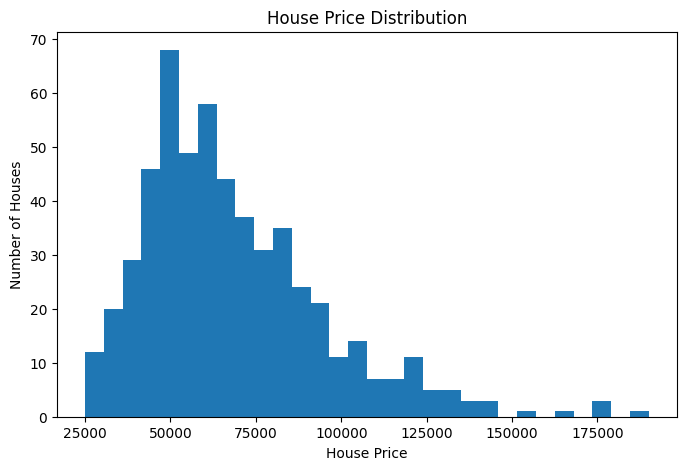

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)
plt.xlabel("House Price")
plt.ylabel("Number of Houses")
plt.title("House Price Distribution")
plt.show()

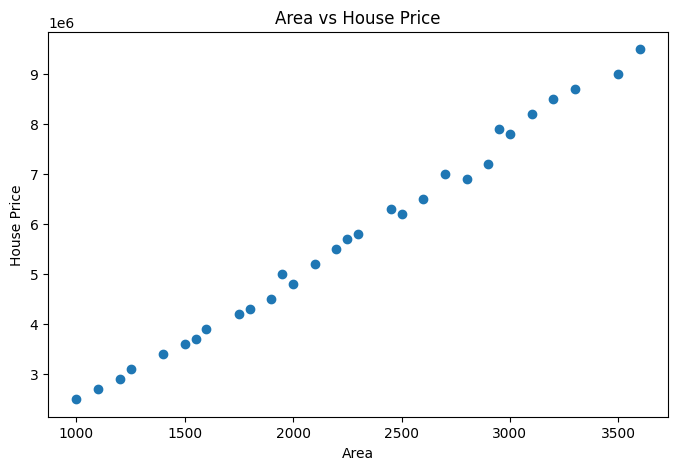

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(df["area"], df["price"])
plt.xlabel("Area")
plt.ylabel("House Price")
plt.title("Area vs House Price")
plt.show()

In [12]:
X = df[["area", "bedrooms", "bathrooms", "stories", "parking"]]
y = df["price"]
print("Input Features:")
print(X.head())
print("\nTarget Variable:")
print(y.head())

Input Features:
   area  bedrooms  bathrooms  stories  parking
0  1000         2          1        1        1
1  1200         2          1        1        1
2  1500         3          2        1        1
3  1800         3          2        2        1
4  2000         3          2        2        2

Target Variable:
0    2500000
1    2900000
2    3600000
3    4300000
4    4800000
Name: price, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (24, 5)
Testing Data: (6, 5)


In [14]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Linear Regression Model trained successfully!")

Linear Regression Model trained successfully!


In [15]:
y_pred = model.predict(X_test)
print("Predicted House Prices:")
print(y_pred[:10])

Predicted House Prices:
[7657441.88149252 5842632.96429505 4992499.34698306 7433175.05446594
 7676070.37369794 8264680.17957251]


In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Model Performance")
print("--------------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

Model Performance
--------------------------
MAE  : 147519.37283582753
MSE  : 30968807746.790356
RMSE : 175979.56627628775
R2 Score : 0.9797442391191051


In [17]:
result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

result.head(10)

,Actual Price,Predicted Price
0,7900000,7.657442e+06
1,5800000,5.842633e+06
2,5000000,4.992499e+06
3,7200000,7.433175e+06
4,7800000,7.676070e+06
5,8500000,8.264680e+06


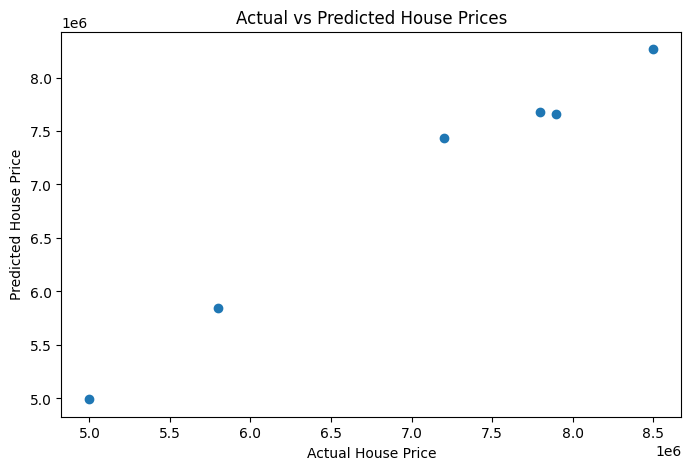

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [19]:
new_house = pd.DataFrame({
    "area": [2000],
    "bedrooms": [3],
    "bathrooms": [2],
    "stories": [2],
    "parking": [1]
})

predicted_price = model.predict(new_house)

print("New House Details:")
print(new_house)

print("\nPredicted House Price:", predicted_price[0])

New House Details:
   area  bedrooms  bathrooms  stories  parking
0  2000         3          2        2        1

Predicted House Price: 4856127.379923817


In [20]:
result.to_csv("house_prediction_results.csv", index=False)
print("Prediction results saved successfully!")

Prediction results saved successfully!
